<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_18_Matplotlib Box Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Data Scientist Hourly Salary Box Plot (2.18.1)

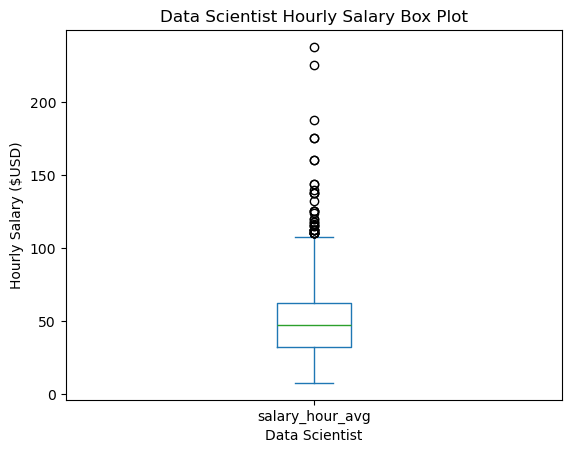

In [16]:
df_DS = df[df['job_title_short'] == 'Data Scientist'].dropna(subset='salary_hour_avg')
df_DS['salary_hour_avg'].plot(kind='box')

plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Data Scientist Hourly Salary Box Plot')
plt.show()

---

## 🟨 Comparison of Hourly Salaries for Data Analyst (2.18.2)

C:\Users\dlam1\AppData\Local\Temp\ipykernel_50556\1377605243.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_list, labels=countries)


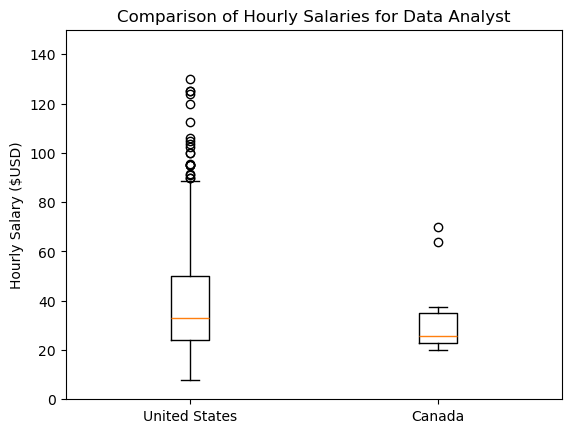

In [11]:
# Code Needed
countries = ['United States', 'Canada']
df_countries_DA = df[(df['job_country'].isin(countries)) & (df['job_title_short'] == 'Data Analyst')].dropna(subset='salary_hour_avg')
country_list = [df_countries_DA[df_countries_DA['job_country'] == country]['salary_hour_avg'] for country in countries]

plt.boxplot(country_list, labels=countries)
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.xlabel('')
plt.title('Comparison of Hourly Salaries for Data Analyst')
plt.show()

---

## 🟥 Comparison of Hourly Salaries in Canada (2.18.3)

C:\Users\dlam1\AppData\Local\Temp\ipykernel_50556\1114319588.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(jobs_list, labels=job_titles)


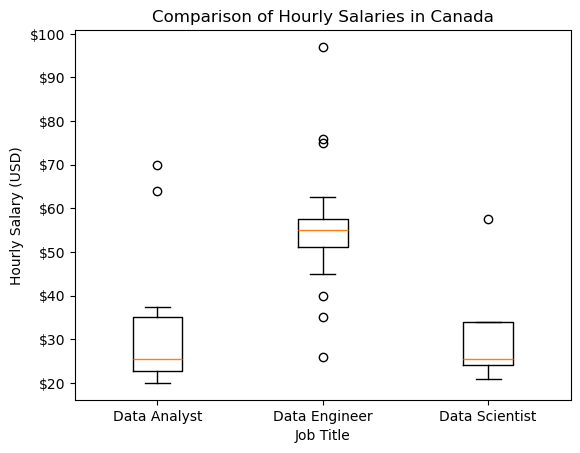

In [ ]:
# Code Needed
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_role_canada = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Canada')].dropna(subset='salary_hour_avg')
jobs_list = [df_role_canada[df_role_canada['job_title_short'] == job_title]['salary_hour_avg'] for job_title in job_titles]

plt.boxplot(jobs_list, labels=job_titles)
ticks_y = plt.FuncFormatter(lambda y, pos: f'${int(y)}')
plt.gca().yaxis.set_major_formatter(ticks_y)

plt.xlabel('Job Title')
plt.ylabel('Hourly Salary (USD)')
plt.title('Comparison of Hourly Salaries in Canada')
plt.show()


---